# Ridge Regression: regularización con intuición

Ridge no se entiende bien si solo decimos que "baja las betas".

Una mejor intuición es esta:

> Ridge le cobra una multa al modelo por usar coeficientes muy grandes.  
> Eso evita modelos exagerados, nerviosos o demasiado sensibles a pequeños cambios en los datos.

La función de costo es:

$$
J(\beta) = \frac{1}{m}\sum_{i=1}^{m}(y_i - \hat{y}_i)^2 + \lambda\sum_{j=1}^{p}\beta_j^2
$$

La primera parte mide qué tanto se equivoca el modelo.  
La segunda parte castiga coeficientes grandes.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')


## Ejemplo 1: cuando el modelo se emociona demasiado

Imagina que tenemos pocos datos y queremos ajustar una curva.

Si dejamos que una regresión polinomial de grado alto haga lo que quiera, puede pasar exactamente por muchos puntos, pero crear una curva ridícula entre ellos.

Ridge ayuda a mantener esa curva más tranquila.


In [2]:
# Datos pequeños con ruido
n = 18
X = np.linspace(0, 10, n).reshape(-1, 1)
y = 3 + 1.2 * X.ravel() + np.sin(1.5 * X.ravel()) * 2 + np.random.normal(0, 1.2, n)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.35, random_state=7
)

x_grid = np.linspace(0, 10, 400).reshape(-1, 1)
grado = 15

modelo_lineal_grado_alto = make_pipeline(
    PolynomialFeatures(degree=grado, include_bias=False),
    StandardScaler(),
    LinearRegression()
)

modelo_ridge = make_pipeline(
    PolynomialFeatures(degree=grado, include_bias=False),
    StandardScaler(),
    Ridge(alpha=20)
)

modelo_lineal_grado_alto.fit(X_train, y_train)
modelo_ridge.fit(X_train, y_train)

pred_train_lineal = modelo_lineal_grado_alto.predict(X_train)
pred_test_lineal = modelo_lineal_grado_alto.predict(X_test)
pred_train_ridge = modelo_ridge.predict(X_train)
pred_test_ridge = modelo_ridge.predict(X_test)

print('Error en entrenamiento')
print(f'Polinomio sin Ridge: {mean_squared_error(y_train, pred_train_lineal):.2f}')
print(f'Polinomio con Ridge: {mean_squared_error(y_train, pred_train_ridge):.2f}')

print('\nError en prueba')
print(f'Polinomio sin Ridge: {mean_squared_error(y_test, pred_test_lineal):.2f}')
print(f'Polinomio con Ridge: {mean_squared_error(y_test, pred_test_ridge):.2f}')


Error en entrenamiento
Polinomio sin Ridge: 0.00
Polinomio con Ridge: 4.05

Error en prueba
Polinomio sin Ridge: 3931.30
Polinomio con Ridge: 2.78


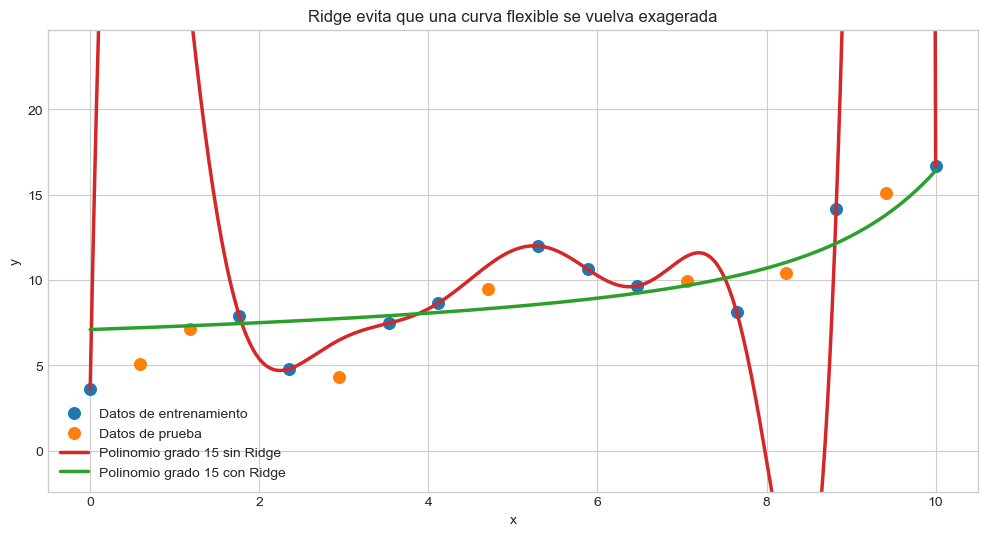

In [3]:
plt.figure(figsize=(12, 6))

plt.scatter(X_train, y_train, color='tab:blue', label='Datos de entrenamiento', s=70)
plt.scatter(X_test, y_test, color='tab:orange', label='Datos de prueba', s=70)

plt.plot(
    x_grid,
    modelo_lineal_grado_alto.predict(x_grid),
    color='tab:red',
    linewidth=2.5,
    label='Polinomio grado 15 sin Ridge'
)

plt.plot(
    x_grid,
    modelo_ridge.predict(x_grid),
    color='tab:green',
    linewidth=2.5,
    label='Polinomio grado 15 con Ridge'
)

plt.title('Ridge evita que una curva flexible se vuelva exagerada')
plt.xlabel('x')
plt.ylabel('y')
plt.ylim(y.min() - 6, y.max() + 8)
plt.legend()
plt.show()


**Idea clave:** el modelo sin Ridge puede tener muy poco error en entrenamiento, pero comportarse raro fuera de esos puntos.

Ridge acepta no perseguir perfectamente cada punto para ganar una curva más estable.


## Ejemplo 2: variables casi duplicadas

Ahora veamos el problema de los coeficientes.

Supón que queremos predecir el precio de una casa usando metros cuadrados. Pero tenemos dos columnas casi iguales:

- `metros_catastro`
- `metros_app`

Las dos miden básicamente lo mismo. Una regresión lineal normal puede confundirse y repartir los coeficientes de forma inestable.


In [4]:
np.random.seed(10)
n = 80

metros_catastro = np.random.normal(120, 35, n)
metros_app = metros_catastro + np.random.normal(0, 3, n)  # casi duplicada
habitaciones = np.round(metros_catastro / 35 + np.random.normal(0, 0.7, n))
ruido = np.random.normal(0, 1, n)

precio = 500_000 + 18_000 * metros_catastro + 80_000 * habitaciones + np.random.normal(0, 450_000, n)

X = pd.DataFrame({
    'metros_catastro': metros_catastro,
    'metros_app': metros_app,
    'habitaciones': habitaciones,
    'ruido_random': ruido,
})
y = precio

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

modelo_lineal = make_pipeline(StandardScaler(), LinearRegression())
modelo_ridge = make_pipeline(StandardScaler(), Ridge(alpha=30))

modelo_lineal.fit(X_train, y_train)
modelo_ridge.fit(X_train, y_train)

pred_lineal = modelo_lineal.predict(X_test)
pred_ridge = modelo_ridge.predict(X_test)

print(f'MSE lineal: {mean_squared_error(y_test, pred_lineal):,.0f}')
print(f'MSE Ridge:  {mean_squared_error(y_test, pred_ridge):,.0f}')
print(f'Correlación entre metros_catastro y metros_app: {X["metros_catastro"].corr(X["metros_app"]):.3f}')


MSE lineal: 203,810,118,007
MSE Ridge:  202,584,165,047
Correlación entre metros_catastro y metros_app: 0.995


In [5]:
coeficientes = pd.DataFrame({
    'variable': X.columns,
    'Regresión lineal': modelo_lineal.named_steps['linearregression'].coef_,
    'Ridge': modelo_ridge.named_steps['ridge'].coef_,
})

coeficientes


,variable,Regresión lineal,Ridge
0,metros_catastro,308342.168503,219290.708895
1,metros_app,266084.891673,220239.187776
2,habitaciones,158634.582654,178488.409447
3,ruido_random,76845.801245,50985.345565


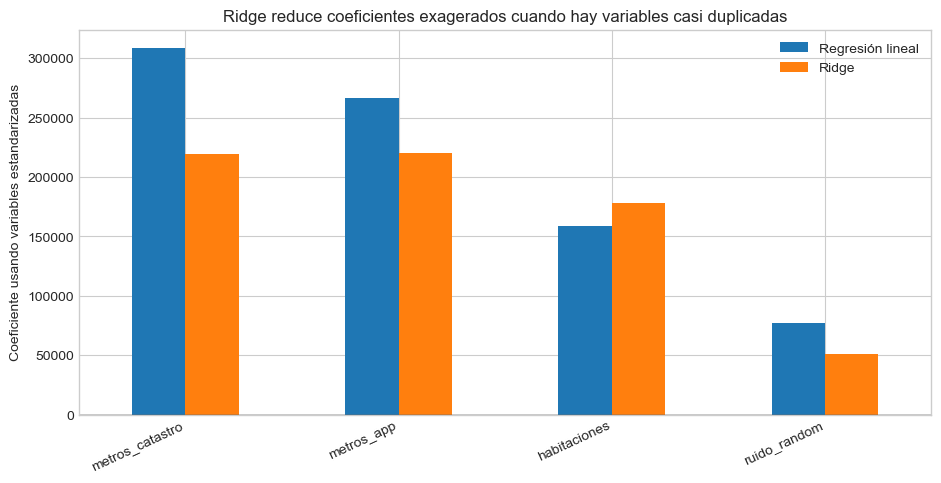

In [6]:
coeficientes.set_index('variable').plot(kind='bar', figsize=(11, 5))
plt.axhline(0, color='black', linewidth=1)
plt.title('Ridge reduce coeficientes exagerados cuando hay variables casi duplicadas')
plt.ylabel('Coeficiente usando variables estandarizadas')
plt.xlabel('')
plt.xticks(rotation=25, ha='right')
plt.show()


## La parte más importante: estabilidad

Si repetimos el entrenamiento varias veces con muestras distintas, la regresión lineal cambia mucho sus coeficientes.

Ridge suele cambiar menos. Esa es una intuición más poderosa que decir solamente que "las betas bajan".


In [7]:
resultados = []

for semilla in range(80):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.35, random_state=semilla
    )

    lineal = make_pipeline(StandardScaler(), LinearRegression())
    ridge = make_pipeline(StandardScaler(), Ridge(alpha=30))

    lineal.fit(X_train, y_train)
    ridge.fit(X_train, y_train)

    for variable, coef in zip(X.columns, lineal.named_steps['linearregression'].coef_):
        resultados.append({'modelo': 'Lineal', 'variable': variable, 'coeficiente': coef})

    for variable, coef in zip(X.columns, ridge.named_steps['ridge'].coef_):
        resultados.append({'modelo': 'Ridge', 'variable': variable, 'coeficiente': coef})

resultados = pd.DataFrame(resultados)


/var/folders/q7/z6bgw1fj4vng6rs97g1chhz00000gn/T/ipykernel_9179/3621228876.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_por_variable, labels=X.columns)
/var/folders/q7/z6bgw1fj4vng6rs97g1chhz00000gn/T/ipykernel_9179/3621228876.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_por_variable, labels=X.columns)


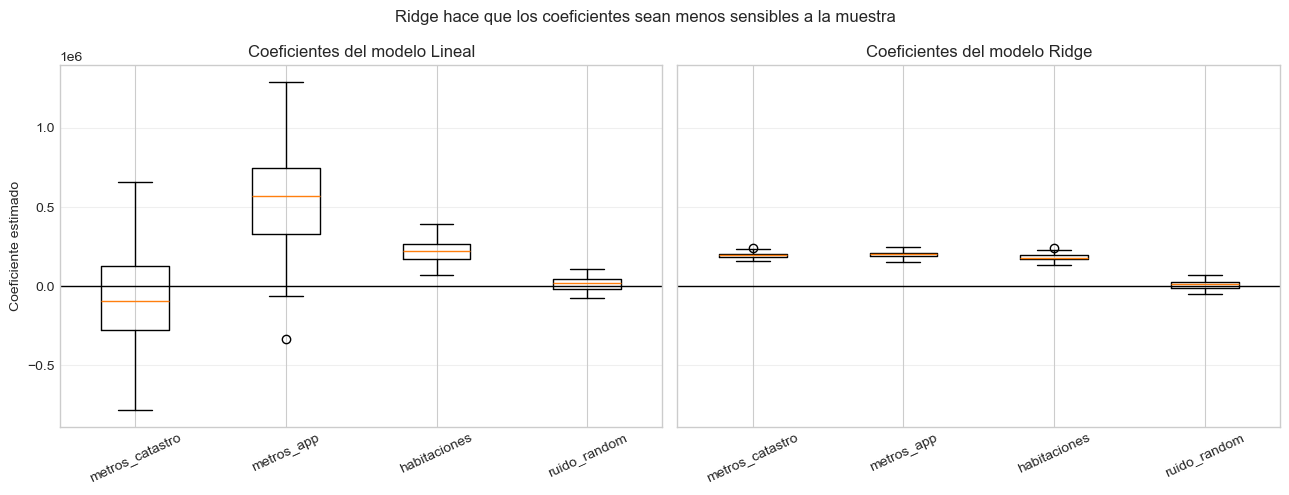

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, modelo in zip(axes, ['Lineal', 'Ridge']):
    subset = resultados[resultados['modelo'] == modelo]
    data_por_variable = [
        subset[subset['variable'] == variable]['coeficiente']
        for variable in X.columns
    ]

    ax.boxplot(data_por_variable, labels=X.columns)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(f'Coeficientes del modelo {modelo}')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(True, axis='y', alpha=0.3)

axes[0].set_ylabel('Coeficiente estimado')
plt.suptitle('Ridge hace que los coeficientes sean menos sensibles a la muestra')
plt.tight_layout()
plt.show()


## Conclusión

Ridge no es solo "hacer más pequeños los coeficientes".

Es una forma de decirle al modelo:

> Puedes ajustar los datos, pero no uses coeficientes enormes a menos que realmente valga la pena.

Por eso ayuda especialmente cuando:

- hay muchas variables,
- hay variables muy correlacionadas,
- el modelo es muy flexible,
- o tenemos pocos datos y mucho ruido.
